# Spatial Visualisations

In [2]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import os
import tifffile
import geopandas as gpd
from skimage import filters

import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Funs

In [3]:
def img_map(img,figsize=(3,3),cmap='viridis',title=None, origin='lower',labels=False,cbar=False,save=None):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(img, cmap=cmap, origin=origin)
    ax.set_title(title)
    if not labels:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])
    if cbar:
        plt.colorbar(im, ax=ax)
    if save is not None:
        plt.savefig(save, dpi=300, bbox_inches='tight', transparent=False) 
    plt.show()

def pctnorm(img, pct_lo = 1, pct_hi = 99.7):
    from skimage import exposure
    p_low, p_high = np.percentile(img, [pct_lo, pct_hi])
    return exposure.rescale_intensity(img, in_range=(p_low, p_high), out_range=(0, 1))

def mask2shapely(masks_in):
    from shapely.geometry import Polygon
    import geopandas as gpd
    from skimage import measure
    import numpy as np
    
    ids = []
    geometries = []

    for i in np.unique(masks_in)[1:]:
        binary_mask = (masks_in == i).astype(np.uint8)
        
        # Find contours using scikit-image
        contours = measure.find_contours(binary_mask, 0.5)
        
        # If multiple contours (disconnected pixels), take the longest one
        if len(contours) > 1:
            longest_contour = max(contours, key=len)
            # Convert from (row, col) to (x, y) coordinates
            coords = longest_contour[:, [1, 0]]
            if len(coords) > 3:
                geometries.append(Polygon(coords))
                ids.append(i)
        else:
            if len(contours) > 0 and len(contours[0]) > 3:
                # Convert from (row, col) to (x, y) coordinates
                coords = contours[0][:, [1, 0]]
                geometries.append(Polygon(coords))
                ids.append(i)
    
    gdf = gpd.GeoDataFrame({'id': ids, 'geometry': geometries}, crs='EPSG:4326')
    gdf = gdf[gdf['id'] != 0]
    gdf['x'] = gdf.geometry.centroid.x
    gdf['y'] = gdf.geometry.centroid.y   

    return gdf

def mask_map(img,mask, figsize=(4,4),fs=None, linewidth=0.75, title=None, origin='upper', cmap='viridis', labels=False):
    if fs is not None:
        figsize=fs


    gdf = mask2shapely(mask)
    
    fig,ax = plt.subplots(figsize=figsize)
    ax.imshow(img, cmap=cmap, interpolation='none', origin=origin)
    gdf.boundary.plot(aspect=1, ax=ax, color='white',linewidth=linewidth)
    ax.set_title(title)
    if not labels:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

### Aes

In [4]:
cell_type_renamer = {
  "Adipocyte"   : "Adipocyte",
  "Bcell"       : "Bcell",
  "CD4_CCR6"    : "CD4 Tcell CCR6+",
  "CD4_GZMB"    : "CD4 Tcell GZMB+",
  "CD4_Other"   : "CD4 Tcell other",
  "CD4_Tex"     : "CD4 Tex",
  "CD4_Tmem"    : "CD4 Tmem",
  "CD4_Tn"      : "CD4 Tnaive",
  "CD4_Treg"    : "CD4 Treg",
  "CD8_GZMB"    : "CD8 Tcell GZMB+",
  "CD8_naive"   : "CD8 Tnaive",
  "CD8_Other"   : "CD8 Tcell other",
  "CD8_Tex"     : "CD8 Tex",
  "CD8_Tmem"    : "CD8 Tmem",
  "DC"          : "DC",
  "EC"          : "EC",
  "Lin-"        : "Unclassified",
  "Mac_M1"      : "M2-like macrophage",
  "Mac_M2"      : "M1-like macrophage",
  "MKs"         : "MK",
  "Mono_CD14"   : "Monocytes CD14+",
  "Mono_CD16"   : "Monocytes CD16+",
  "Mye_HLADR"   : "Myeloid HLA-DR+",
  "Mye_other"   : "Myeloid other",
  "Myeloma"     : "Myeloma",
  "NK"          : "NK cells",
  "Myeloid":"Myeloid",
  "T":"Tcell"
}
cell_type_renamer 
color_palette_26_clean = {
  # CD4 (purples)
  "CD4 Tcell CCR6+" : "#6A51A3",
  "CD4 Tcell GZMB+" : "#9E9AC8",
  "CD4 Tcell other" : "#807DBA",
  "CD4 Tex"         : "#BCBDDC",
  "CD4 Tmem"        : "#D5D3E6",
  "CD4 Tnaive"      : "#E6E4F1",
  "CD4 Treg"        : "#B39DD8",
  
  # CD8 (blues)
  "CD8 Tcell GZMB+" : "#08519C",
  "CD8 Tcell other" : "#2171B5",
  "CD8 Tex"         : "#6BAED6",
  "CD8 Tmem"        : "#9ECAE1",
  "CD8 Tnaive"      : "#C6DBEF",
  
  # Myeloid / APC (greens → yellow-greens)
  "DC"                 : "#8C6BB1",  
  "M1-like macrophage" : "#005A32",  
  "M2-like macrophage" : "#238B45",  
  "Monocytes CD14+"    : "#66C2A4", 
  "Monocytes CD16+"    : "#A1D99B",  
  "Myeloid HLA-DR+"    : "#C7E9B4", 
  "Myeloid other"      :"#E5F5E0",   
  
  # Other lineages (distinct hues)
  "Bcell"        : "#C49A6C",  
  "EC"           : "#E5842B",  
  "MK"           : "gold",  
  "NK cells"     : "#D25C9E",  
  "Adipocyte"    : "#F6E8C3",  
  "Unclassified" : "lightgrey" ,  
  
  # Keep Myeloma red
  "Myeloma"      : "#FF0000"
}

### Create NEW merged MK `gpd`

In [5]:
def prep_gdf(sample_id):
    #import md
    obs_v5 = pd.read_csv('/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/obs_v5.csv')
    obs_sub = obs_v5[obs_v5.sample_id==sample_id][['Cell_ID','lineage','ph','gated']]
    
    gdf = gpd.read_file(f'/mnt/disks/data/imc/CART_cohort/out/sample_data/{sample_id}/segmentation_masks/mask_V1withAdipo_gdf.geojson')
    
    mask = tifffile.imread(f'/mnt/disks/data/imc/CART_cohort/out/sample_data/{sample_id}/segmentation_masks/mask_V1withAdipo_MKv2.tif')
    mask_MK = np.where(np.isin(mask,obs_sub[obs_sub.lineage=='MKs'].Cell_ID),mask,0)

    #merge
    gdf = gdf.merge(obs_sub, how='left', left_on='id',right_on='Cell_ID')

    #re-calc for MKs
    gdf_nonMK = gdf[~((gdf.ph.isna())|(gdf.ph=='MK'))]
    gdf_MK = mask2shapely(mask_MK)
    gdf_MK = gdf_MK.drop(['x','y'],axis=1).merge(obs_sub, how='left', left_on='id',right_on='Cell_ID')

    #merge final
    gdf = pd.concat([gdf_nonMK,gdf_MK])

    return gdf

In [6]:
md = pd.read_csv("/mnt/disks/data/imc/CART_cohort/in/sample_md.csv")
samples_used = []
from tqdm import tqdm

for sample_id in tqdm(md['sample'].unique()):
    #print(sample_id)
    if len(os.listdir(f"/mnt/disks/data/imc/CART_cohort/in/sample_gating/{sample_id}"))==0:
        continue
    if 'mask_V1withAdipo_gdf.geojson' not in os.listdir(f'/mnt/disks/data/imc/CART_cohort/out/sample_data/{sample_id}/segmentation_masks/'):
        continue 
    #if f"{sample_id}.png" in os.listdir(f'/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/ROI_pheno_maps_v3'):
    #    continue
    
    gdf = prep_gdf(sample_id)

    gdf.to_file(f'/mnt/disks/data/imc/CART_cohort/out/sample_data/{sample_id}/segmentation_masks/mask_V1withAdipo_MKv2_gdf.geojson', driver='GeoJSON')

100%|██████████| 132/132 [25:08<00:00, 11.43s/it]


### Phenotype Map

In [ ]:
def make_plot(gdf,sample_id):

    gdf['label']=gdf['ph'].map(cell_type_renamer)
    gdf['color']=gdf['label'].map(color_palette_26_clean)

    gdf = gdf[gdf.gated]
    gdf = gdf[~gdf.lineage.isin(['B-T', 'Artifact'])]

    import matplotlib.patches as mpatches
    
    fig,ax = plt.subplots(figsize=(7,7))
    
    gdf.plot(aspect=1, ax=ax, color=gdf["color"], edgecolor='black', linewidth=0.15, alpha=1)
    
    unique_entries = gdf.drop_duplicates(subset=["label", "color"])
    handles = [
        mpatches.Patch(facecolor=row["color"], edgecolor='black', label=row["label"])
        for _, row in unique_entries.iterrows()
    ]
    ax.legend(handles=handles,bbox_to_anchor=(1.05, 1), ncol=2,loc="upper left")
    
    ax.set_title(sample_id)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_axis_off()
        
    plt.savefig(f'/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/ROI_pheno_maps_v3/{sample_id}.png', dpi=300, bbox_inches='tight', transparent=False) 
    plt.close()
    plt.clf()
    plt.cla()
    import gc
    gc.collect()

In [ ]:
md = pd.read_csv("/mnt/disks/data/imc/CART_cohort/in/sample_md.csv")
samples_used = []
from tqdm import tqdm

for sample_id in (md['sample'].unique()):

    if len(os.listdir(f"/mnt/disks/data/imc/CART_cohort/in/sample_gating/{sample_id}"))==0:
        continue
    if 'mask_V1withAdipo_gdf.geojson' not in os.listdir(f'/mnt/disks/data/imc/CART_cohort/out/sample_data/{sample_id}/segmentation_masks/'):
        continue 
    if f"{sample_id}.png" in os.listdir(f'/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/ROI_pheno_maps_v3'):
        continue

    gdf = gpd.read_file(f'/mnt/disks/data/imc/CART_cohort/out/sample_data/{sample_id}/segmentation_masks/mask_V1withAdipo_MKv2_gdf.geojson')
    make_plot(gdf,sample_id)

### CN Maps

In [100]:
def make_plot(gdf, sample_id):

    gdf['label']=gdf['cn_labels']
    gdf['color']=gdf['label'].map(CN_col)
    
    import matplotlib.patches as mpatches
    
    fig,ax = plt.subplots(figsize=(9,9))
    
    gdf.plot(aspect=1, ax=ax, color=gdf["color"], edgecolor='black', linewidth=0.15, alpha=1)
    
    unique_entries = gdf.drop_duplicates(subset=["label", "color"])
    handles = [
        mpatches.Patch(facecolor=row["color"], edgecolor='black', label=row["label"])
        for _, row in unique_entries.iterrows()
    ]
    ax.legend(handles=handles,bbox_to_anchor=(1.05, 1), ncol=2,loc="upper left")
    
    ax.set_title(sample_id)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_axis_off()
    
    plt.savefig(f'/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/ROI_CN_Maps/{cn_id}/{sample_id}.png', dpi=300, bbox_inches='tight', transparent=False) 
    plt.close()
    plt.clf()
    plt.cla()
    import gc
    gc.collect()

In [94]:
CN_col = dict(zip(
    ['CN'+str(i) for i in range(0,15)],
    ["#6A3D9A","#2171B5","#FF0000","#8C6BB1","#66C2A4","#005A32", "#C49A6C","#E5842B",
     "gold", "#D25C9E","#F6E8C3", "#9ECAE1","brown","#FF13F0","#FB9A99"]
))
CN_col['NA'] = "#b8b8b8"

#### bslTP_linNegOut_15clus

In [109]:
cn_id = "bslTP_linNegOut_15clus"
cn_cells_data = pd.read_csv(f'/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/cn_data/{cn_id}-cells_data.csv')

100%|██████████| 97/97 [05:23<00:00,  3.33s/it]


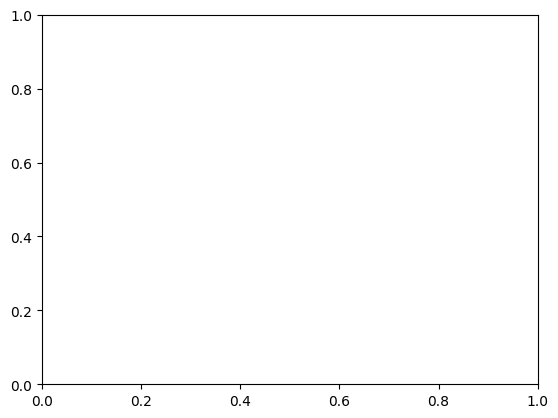

In [110]:
md = pd.read_csv("/mnt/disks/data/imc/CART_cohort/in/sample_id-clinical.csv")
samples_used = []
from tqdm import tqdm

for sample_id in tqdm(md[md.Timepoint=='Baseline'].sample_id.unique()):

    if sample_id not in cn_cells_data.sample_id.unique():
        continue 
    if f"{sample_id}.png" in os.listdir(f'/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/ROI_CN_Maps/{cn_id}/'):
        continue

    cn_cells_sample = cn_cells_data[cn_cells_data.sample_id==sample_id]
    cn_cells_sample = cn_cells_sample[['Cell_ID','cn_labels']]
    
    gdf = gpd.read_file(f'/mnt/disks/data/imc/CART_cohort/out/sample_data/{sample_id}/segmentation_masks/mask_V1withAdipo_MKv2_gdf.geojson')
    gdf.Cell_ID=gdf.Cell_ID.astype(int)
    
    gdf = gdf[gdf.gated=='True']
    gdf = gdf.merge(cn_cells_sample, how='left').fillna('NA')

    make_plot(gdf, sample_id)

#### postTP_linNegOut_15clus

In [114]:
cn_id = "postTP_linNegOut_15clus"
cn_cells_data = pd.read_csv(f'/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/cn_data/{cn_id}-cells_data.csv')

100%|██████████| 36/36 [01:41<00:00,  2.81s/it]


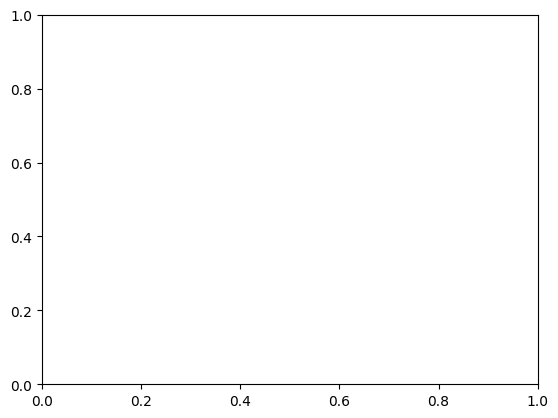

In [115]:
md = pd.read_csv("/mnt/disks/data/imc/CART_cohort/in/sample_id-clinical.csv")
samples_used = []
from tqdm import tqdm

for sample_id in tqdm(md[md.Timepoint=='01MOpost'].sample_id.unique()):

    if sample_id not in cn_cells_data.sample_id.unique():
        continue 
    if f"{sample_id}.png" in os.listdir(f'/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/ROI_CN_Maps/{cn_id}/'):
        continue

    cn_cells_sample = cn_cells_data[cn_cells_data.sample_id==sample_id]
    cn_cells_sample = cn_cells_sample[['Cell_ID','cn_labels']]
    
    gdf = gpd.read_file(f'/mnt/disks/data/imc/CART_cohort/out/sample_data/{sample_id}/segmentation_masks/mask_V1withAdipo_MKv2_gdf.geojson')
    gdf.Cell_ID=gdf.Cell_ID.astype(int)
    
    gdf = gdf[gdf.gated=='True']
    gdf = gdf.merge(cn_cells_sample, how='left').fillna('NA')

    make_plot(gdf, sample_id)